# Activation functions: from bends to gates

**The whole idea in one sentence:** a stack of weighted sums is just one weighted
sum, so something bent has to sit between the matrices — and in a modern
transformer that bent thing is no longer a curve, but a second weighted sum that
*multiplies* the first.

The attention notebook ([full_attention](../mixers/full_attention.ipynb)) was about
the half of a block that moves information between tokens. This one is about the
other half, the MLP, where each token is processed on its own — and about the small
function inside it that everything else depends on.

By the end you'll have:

- stacked twenty matrices with nothing between them and watched them **collapse into
  one**, then built `|x|` out of two ReLUs
- tabulated the five activations that matter — sigmoid, tanh, ReLU, GELU, SiLU — and
  their slopes, which are what training actually sees
- pushed a gradient back through twenty sigmoids and watched it arrive **five
  trillion times smaller**
- killed 64 ReLU units and watched Adam fail to revive a single one, while the same
  units with GELU come back
- seen that a **gate** is nothing but a number you multiply by — and that ReLU was a
  gate all along
- computed a SwiGLU layer by hand, every number printed
- taught `a × b` to a plain MLP and to a gated one: **one gated channel is exact where
  sixteen plain ones are not**
- made the comparison unfair by accident, the way papers sometimes do, and fixed it
  with the 2/3 rule

In [1]:
import math

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
np.set_printoptions(precision=3, suppress=True, linewidth=110)
torch.set_printoptions(precision=3, sci_mode=False, linewidth=110)

try:
    import matplotlib.pyplot as plt
    HAVE_MPL = True
except ImportError:
    HAVE_MPL = False
    print("matplotlib not installed - plot cells will print a note instead (uv sync --extra demo)")

SURFACE, INK, INK2, GRID = "#fcfcfb", "#1f1e1d", "#6b6a63", "#e8e7e3"
BLUE, ORANGE, AQUA, YELLOW, MAGENTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
COLOR = {"sigmoid": BLUE, "tanh": ORANGE, "relu": AQUA, "gelu": YELLOW, "silu": MAGENTA}   # one colour per function, in every plot

def style(ax):
    ax.set_facecolor(SURFACE); ax.set_axisbelow(True)
    ax.grid(color=GRID, lw=0.6)
    ax.tick_params(colors=INK2, labelsize=8)
    for s in ax.spines.values():
        s.set_visible(False)

---
## 1. Why bend at all

Take the smallest possible network: one number in, one number out, two layers with
weights 2 and 3 and nothing between them.

```
y = 3 · (2 · x) = 6 · x
```

Two layers, and the result is one layer with weight 6. That isn't a coincidence of
these numbers. Multiplying by one matrix and then another is the same as multiplying
by their product, so **any stack of plain matrices, however deep, is one matrix.**
Check it with twenty of them:

In [2]:
g = torch.Generator().manual_seed(0)
layers = [torch.randn(8, 8, generator=g) / math.sqrt(8) for _ in range(20)]
x = torch.randn(8, generator=g)

deep = x
for W in layers:
    deep = W @ deep                       # twenty layers, one after the other

one = torch.eye(8)
for W in layers:
    one = W @ one                         # multiply the twenty matrices together first...
print("twenty layers == one matrix:", torch.allclose(deep, one @ x, atol=1e-5))   # ...and it's the same thing

twenty layers == one matrix: True


Depth bought nothing. A twenty-layer network with nothing between its layers can only
draw straight lines (flat planes, in more dimensions), exactly like a one-layer one.

Now put ReLU between them — `relu(z) = max(0, z)`, flat for negatives, unchanged for
positives. A single ReLU has one kink. Two of them, facing opposite ways, add up to a
shape no matrix can make:

In [3]:
relu = lambda z: z.clamp(min=0)
xs = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])

print("       x:", xs.tolist())
print(" relu(x):", relu(xs).tolist())
print("relu(-x):", (relu(-xs) + 0.0).tolist())                   # + 0.0 turns -0.0 into 0.0
print("     sum:", (relu(xs) + relu(-xs)).tolist(), " <- |x|, a V")

# the best any straight line can do on the same V: fit y = a·x + b by least squares
grid = torch.linspace(-2, 2, 101)
A = torch.stack([grid, torch.ones_like(grid)], dim=1)
a, b = torch.linalg.lstsq(A, grid.abs().unsqueeze(1)).solution.squeeze().tolist()
print(f"\nbest straight line through |x|: y = {a:.2f}·x + {b:.2f}   (flat - it can only split the difference)")

       x: [-2.0, -1.0, 0.0, 1.0, 2.0]
 relu(x): [0.0, 0.0, 0.0, 1.0, 2.0]
relu(-x): [2.0, 1.0, 0.0, 0.0, 0.0]
     sum: [2.0, 1.0, 0.0, 1.0, 2.0]  <- |x|, a V

best straight line through |x|: y = 0.00·x + 1.01   (flat - it can only split the difference)


The best a line can do with a V is give up and go flat through the middle. Two kinks
make it exactly. More kinks can trace any curve you like, one straight piece at a time.

**That is the entire job of an activation function: put a bend between the matrices so
they stop collapsing.** Everything else in this notebook is about *which* bend, and
what it does to training.

---
## 2. Five bends, as numbers

The five that matter, each written out rather than imported:

| name | formula | in words |
|---|---|---|
| sigmoid | `1 / (1 + e^-x)` | squash anything into 0..1 |
| tanh | `(e^x - e^-x) / (e^x + e^-x)` | the same S-curve, stretched to -1..1 |
| ReLU | `max(0, x)` | keep positives, zero negatives |
| GELU | `x · Φ(x)` | keep `x` with the probability a standard normal falls below it |
| SiLU | `x · sigmoid(x)` | the same idea with sigmoid in place of `Φ`. Also called Swish |

In [4]:
def sigmoid(z): return 1 / (1 + torch.exp(-z))
def tanh(z):    return (torch.exp(z) - torch.exp(-z)) / (torch.exp(z) + torch.exp(-z))
def gelu(z):    return z * 0.5 * (1 + torch.erf(z / math.sqrt(2)))      # Φ, the normal CDF, via erf
def silu(z):    return z * sigmoid(z)

ACTS = {"sigmoid": sigmoid, "tanh": tanh, "relu": relu, "gelu": gelu, "silu": silu}

print(f"{'x':>9}" + "".join(f"{v:>9.0f}" for v in xs))
for name, f in ACTS.items():
    print(f"{name:>9}" + "".join(f"{v:>9.3f}" for v in f(xs)))

torch_versions = {"sigmoid": torch.sigmoid, "tanh": torch.tanh, "relu": F.relu, "gelu": F.gelu, "silu": F.silu}
wide = torch.linspace(-8, 8, 1001)
print("\nall five match PyTorch's:", all(torch.allclose(ACTS[n](wide), torch_versions[n](wide), atol=1e-6) for n in ACTS))

        x       -2       -1        0        1        2
  sigmoid    0.119    0.269    0.500    0.731    0.881
     tanh   -0.964   -0.762    0.000    0.762    0.964
     relu    0.000    0.000    0.000    1.000    2.000
     gelu   -0.046   -0.159    0.000    0.841    1.954
     silu   -0.238   -0.269    0.000    0.731    1.762

all five match PyTorch's: True


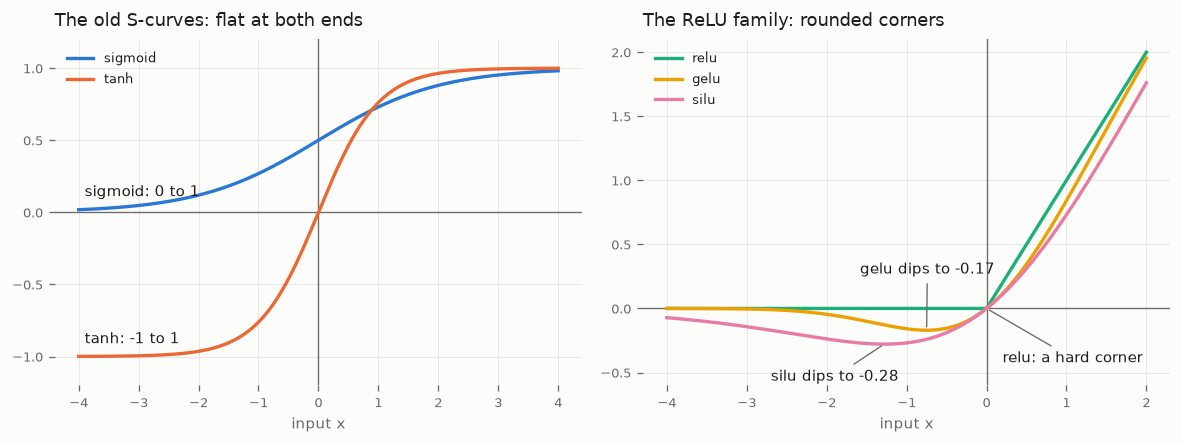

In [5]:
if HAVE_MPL:
    z = torch.linspace(-4, 4, 401)
    fig, (left, right) = plt.subplots(1, 2, figsize=(10, 3.8), dpi=120)
    fig.patch.set_facecolor(SURFACE)
    for ax in (left, right):
        style(ax)
        ax.axhline(0, color=INK2, lw=0.8); ax.axvline(0, color=INK2, lw=0.8)
        ax.set_xlabel("input x", color=INK2, fontsize=9)

    for name in ("sigmoid", "tanh"):
        left.plot(z, ACTS[name](z), color=COLOR[name], lw=2, label=name)
    left.annotate("sigmoid: 0 to 1", (-3.9, float(sigmoid(torch.tensor(-3.9)))), xytext=(0, 8), textcoords="offset points", color=INK, fontsize=9)
    left.annotate("tanh: -1 to 1", (-3.9, -1.0), xytext=(0, 8), textcoords="offset points", color=INK, fontsize=9)
    left.set_ylim(-1.2, 1.2)
    left.set_title("The old S-curves: flat at both ends", color=INK, fontsize=10.5, loc="left", pad=8)
    left.legend(loc="upper left", fontsize=8, frameon=False, labelcolor=INK)

    z2 = torch.linspace(-4, 2, 401)
    for name in ("relu", "gelu", "silu"):
        right.plot(z2, ACTS[name](z2), color=COLOR[name], lw=2, label=name)
    right.annotate("relu: a hard corner", (0, 0), xytext=(0.2, -0.42), color=INK, fontsize=9,
                   arrowprops=dict(arrowstyle="-", color=INK2, lw=0.8))
    right.annotate("gelu dips to -0.17", (-0.75, -0.17), xytext=(-40, 34), textcoords="offset points", color=INK, fontsize=9,
                   arrowprops=dict(arrowstyle="-", color=INK2, lw=0.8))
    right.annotate("silu dips to -0.28", (-1.28, -0.278), xytext=(-68, -22), textcoords="offset points", color=INK, fontsize=9,
                   arrowprops=dict(arrowstyle="-", color=INK2, lw=0.8))
    right.set_ylim(-0.6, 2.1)
    right.set_title("The ReLU family: rounded corners", color=INK, fontsize=10.5, loc="left", pad=8)
    right.legend(loc="upper left", fontsize=8, frameon=False, labelcolor=INK)
    fig.tight_layout()
    plt.show()
else:
    print("(plot skipped)")

Two families. **Sigmoid and tanh** are S-curves that flatten out at both ends. Sigmoid's
0..1 range makes it a natural "how open is this?" dial, which is the job it still has
today, inside gates (section 5). Tanh is the same curve centred on zero — in fact
`tanh(x) = 2·sigmoid(2x) - 1`.

**ReLU, GELU and SiLU** all keep large positives and kill large negatives. ReLU does it
with a hard corner. GELU and SiLU round the corner off and let a little negative value
through, dipping below zero before returning to it. They're nearly the same curve — a
common shortcut is `GELU(x) ≈ x · sigmoid(1.702·x)`, and section 4 measures how good
that shortcut is.

---
## 3. The slope is what training sees

The values above are what the forward pass sees. Training sees something else. The
gradient flows backwards through every activation and is **multiplied by its slope** at
the point where the input landed. So the slope, not the value, decides whether a layer
can learn.

Ask autograd for the slope of each function at three points:

In [6]:
def slope(f, x0):
    t = torch.tensor(x0, requires_grad=True)
    f(t).backward()
    return t.grad.item()

print(f"{'slope at':>9}{'x = -3':>10}{'x = 0':>10}{'x = 3':>10}")
for name, f in ACTS.items():
    print(f"{name:>9}" + "".join(f"{slope(f, x0):>10.4f}" for x0 in (-3.0, 0.0, 3.0)))

 slope at    x = -3     x = 0     x = 3
  sigmoid    0.0452    0.2500    0.0452
     tanh    0.0099    1.0000    0.0099
     relu    0.0000    1.0000    1.0000
     gelu   -0.0119    0.5000    1.0119
     silu   -0.0881    0.5000    1.0881


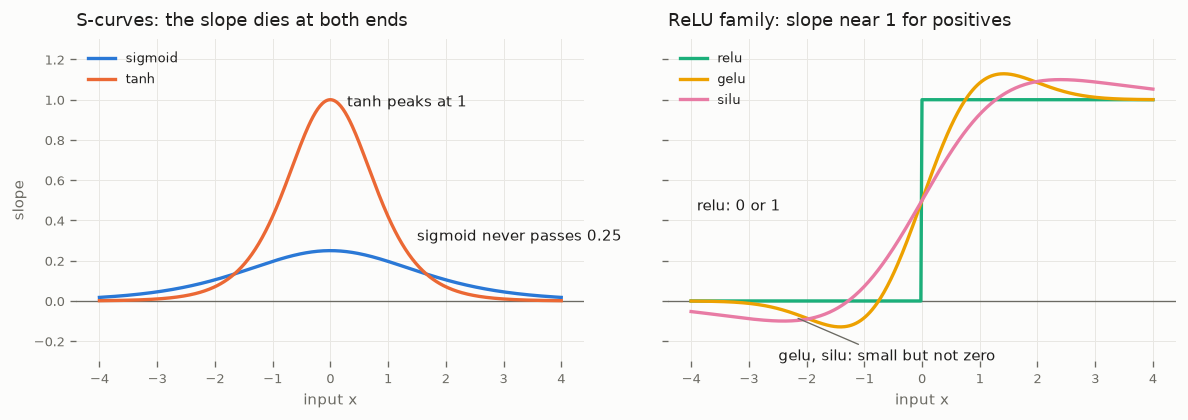

In [7]:
if HAVE_MPL:
    def slopes(f, z):
        z = z.clone().requires_grad_(True)
        f(z).sum().backward()
        return z.grad
    z = torch.linspace(-4, 4, 401)
    fig, (left, right) = plt.subplots(1, 2, figsize=(10, 3.6), dpi=120, sharey=True)
    fig.patch.set_facecolor(SURFACE)
    for ax in (left, right):
        style(ax)
        ax.axhline(0, color=INK2, lw=0.8)
        ax.set_xlabel("input x", color=INK2, fontsize=9)
    for name in ("sigmoid", "tanh"):
        left.plot(z, slopes(ACTS[name], z), color=COLOR[name], lw=2, label=name)
    left.annotate("sigmoid never passes 0.25", (1.5, 0.3), color=INK, fontsize=9)
    left.annotate("tanh peaks at 1", (0, 1.0), xytext=(10, -4), textcoords="offset points", color=INK, fontsize=9)
    left.set_ylabel("slope", color=INK2, fontsize=9)
    left.set_title("S-curves: the slope dies at both ends", color=INK, fontsize=10.5, loc="left", pad=8)
    left.legend(loc="upper left", fontsize=8, frameon=False, labelcolor=INK)
    for name in ("relu", "gelu", "silu"):
        right.plot(z, slopes(ACTS[name], z), color=COLOR[name], lw=2, label=name)
    right.annotate("relu: 0 or 1", (-3.9, 0.45), color=INK, fontsize=9)
    right.annotate("gelu, silu: small but not zero", (-2.2, -0.08), xytext=(-10, -26), textcoords="offset points", color=INK, fontsize=9,
                   arrowprops=dict(arrowstyle="-", color=INK2, lw=0.8))
    right.set_title("ReLU family: slope near 1 for positives", color=INK, fontsize=10.5, loc="left", pad=8)
    right.legend(loc="upper left", fontsize=8, frameon=False, labelcolor=INK)
    right.set_ylim(-0.3, 1.3)
    fig.tight_layout()
    plt.show()
else:
    print("(plot skipped)")

Two numbers in that table decided the history of deep learning:

- **Sigmoid's slope is never above 0.25.** Pass back through ten sigmoids and the gradient
  is multiplied by at most `0.25^10`, about one in a million.
- **ReLU's slope is exactly 1 or exactly 0.** On the positive side, gradients pass through
  undamaged, which is why it replaced sigmoid. On the negative side they don't pass at all.

Both of those are traps. Here they are, sprung.

### Break it on purpose: twenty sigmoids

A 20-layer network, 64 wide, run once forwards and once backwards. Each stack gets the
starting weight scale designed for its own activation (PyTorch's `calculate_gain`), so
none of them loses because of a bad start. Then measure how big the gradient is at every
layer:

In [8]:
GAIN = {"sigmoid": 1.0, "tanh": 5 / 3, "relu": math.sqrt(2), "gelu": math.sqrt(2)}

def grad_profile(act, gain, depth=20, width=64):
    g = torch.Generator().manual_seed(0)
    Ws = [torch.randn(width, width, generator=g) * gain / math.sqrt(width) for _ in range(depth)]
    for W in Ws:
        W.requires_grad_(True)
    h = torch.randn(256, width, generator=g)
    for W in Ws:
        h = act(h @ W.T)
    h.pow(2).mean().backward()
    return [W.grad.norm().item() for W in Ws]        # how big each layer's gradient is

profiles = {name: grad_profile(ACTS[name], GAIN[name]) for name in GAIN}
print("gradient size at layer 1, as a fraction of layer 20's:\n")
for name, p in profiles.items():
    print(f"   {name:8} {p[0] / p[-1]:.1e}")

gradient size at layer 1, as a fraction of layer 20's:

   sigmoid  2.1e-13
   tanh     2.0e+00
   relu     3.7e-01
   gelu     2.7e+00


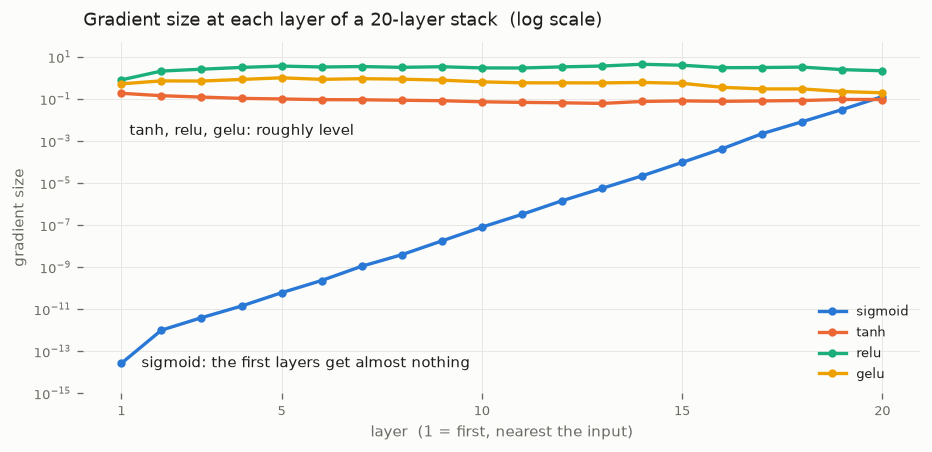

In [9]:
if HAVE_MPL:
    fig, ax = plt.subplots(figsize=(9, 3.8), dpi=120)
    fig.patch.set_facecolor(SURFACE); style(ax)
    layers_ax = range(1, 21)
    for name, p in profiles.items():
        ax.plot(layers_ax, p, color=COLOR[name], lw=2, marker="o", ms=4, label=name)
    ax.set_yscale("log")
    ax.annotate("sigmoid: the first layers get almost nothing", (1, profiles["sigmoid"][0]), xytext=(12, 0),
                textcoords="offset points", color=INK, fontsize=9, va="center")
    ax.annotate("tanh, relu, gelu: roughly level", (1.2, 3e-3), color=INK, fontsize=9, va="center")
    ax.set_ylim(1e-15, 50)
    ax.set_xticks([1, 5, 10, 15, 20])
    ax.set_title("Gradient size at each layer of a 20-layer stack  (log scale)", color=INK, fontsize=11, loc="left", pad=10)
    ax.set_xlabel("layer  (1 = first, nearest the input)", color=INK2, fontsize=9)
    ax.set_ylabel("gradient size", color=INK2, fontsize=9)
    ax.legend(loc="lower right", fontsize=8, frameon=False, labelcolor=INK)
    plt.show()
else:
    print("(plot skipped)")

Layer 20 gets a normal gradient. Layer 1 of the sigmoid stack gets about **five trillion
times less** — twenty slopes of at most 0.25, multiplied together, on top of sigmoid's
outputs all being positive, which pushes every layer's inputs off-centre. In practice
the first layers of that network never train. This is the *vanishing gradient*, and it
is a large part of why deep networks were so hard to train before about 2010.

The other three stay within a factor of a few across all twenty layers. And nothing
crashed: the sigmoid network runs, produces a loss, and would report that it was
training. Only its last few layers would be doing any of the work.

### Break it on purpose: units that never come back

ReLU's zero slope has its own failure. A unit whose input is negative for every example
outputs zero, gets a gradient of exactly zero, and so never changes. It is *dead*.

Kill 64 of them deliberately — start every bias at -4, so every input lands far on the
negative side — then train on a simple regression task with Adam and count, every ten
steps, how many units never switch on for any example:

In [10]:
def dead_run(act, steps=300):
    torch.manual_seed(0)
    layer, head = nn.Linear(16, 64), nn.Linear(64, 1)
    with torch.no_grad():
        layer.bias.fill_(-4.0)                                    # every unit starts far below zero
    opt = torch.optim.Adam([*layer.parameters(), *head.parameters()], lr=1e-2)
    g = torch.Generator().manual_seed(1)
    X = torch.randn(512, 16, generator=g)
    y = X[:, :4].sum(-1, keepdim=True).sin()

    def dead():                                                   # units positive for no example at all
        with torch.no_grad():
            return int(((layer(X) > 0).sum(0) == 0).sum())

    history = []
    for step in range(steps + 1):
        if step % 10 == 0:
            history.append(dead())
        if step == steps:
            break
        loss = F.mse_loss(head(act(layer(X))), y)
        opt.zero_grad(); loss.backward(); opt.step()
    return history, loss.item()

dead = {name: dead_run(ACTS[name]) for name in ("relu", "gelu", "silu")}
print("dead units out of 64:\n")
for name, (hist, loss) in dead.items():
    print(f"   {name:5} at the start {hist[0]:>3}    after 300 steps {hist[-1]:>3}    final loss {loss:.4f}")

dead units out of 64:

   relu  at the start  64    after 300 steps  64    final loss 0.5085
   gelu  at the start  64    after 300 steps   1    final loss 0.0025
   silu  at the start  64    after 300 steps  14    final loss 0.0004


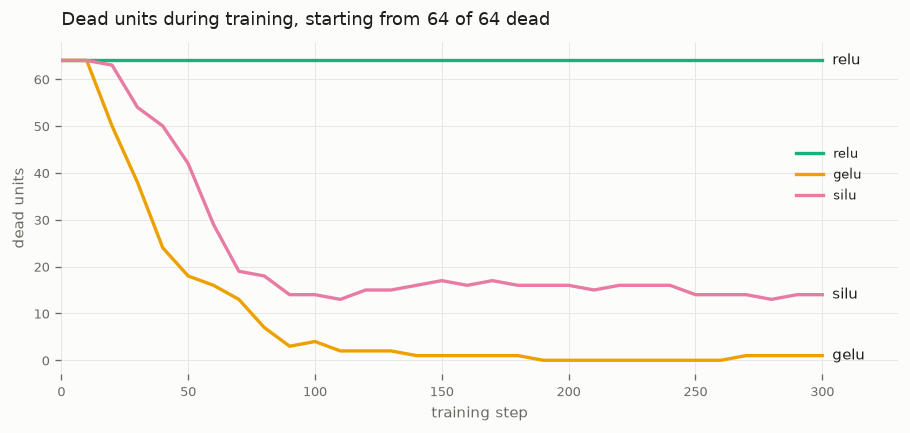

In [11]:
if HAVE_MPL:
    fig, ax = plt.subplots(figsize=(9, 3.6), dpi=120)
    fig.patch.set_facecolor(SURFACE); style(ax)
    steps_ax = range(0, 301, 10)
    for name, (hist, _) in dead.items():
        ax.plot(steps_ax, hist, color=COLOR[name], lw=2, label=name)
        ax.annotate(name, (300, hist[-1]), xytext=(6, 0), textcoords="offset points", color=INK, fontsize=9, va="center")
    ax.set_xlim(0, 330); ax.set_ylim(-3, 68)
    ax.set_title("Dead units during training, starting from 64 of 64 dead", color=INK, fontsize=11, loc="left", pad=10)
    ax.set_xlabel("training step", color=INK2, fontsize=9); ax.set_ylabel("dead units", color=INK2, fontsize=9)
    ax.legend(loc="center right", bbox_to_anchor=(0.97, 0.6), fontsize=8, frameon=False, labelcolor=INK)
    plt.show()
else:
    print("(plot skipped)")

The ReLU layer ends as it began: **64 of 64 dead**, and a loss that never moved. The GELU
and SiLU layers climb out.

What people expect, and it isn't so: that a smart optimiser rescues this. Adam divides
each step by the gradient's recent size, so it happily turns a *tiny* gradient into a
full-sized step — which is exactly how GELU's slope down there, a few thousandths at
most, gets its units moving. But a gradient of exactly zero stays zero after any rescaling. Adam has nothing
to amplify.

A real network rarely starts this badly. But a large learning-rate spike can push a
chunk of units negative mid-training, and with ReLU they don't come back. With a rounded
corner, they can.

---
## 4. GELU and SiLU up close

Two curves that look the same, used by different model families: GELU by BERT, GPT-2 and
nanoGPT; SiLU by Llama-style models, inside SwiGLU. How far apart are they, and how good
are the shortcuts people use for GELU?

GPT-2's code didn't compute `Φ` exactly. It used the tanh-based approximation given in
the original GELU paper, and its published weights were trained with it.

In [12]:
x = torch.linspace(-6, 6, 10001, dtype=torch.float64)
exact = gelu(x)
tanh_approx = 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * x**3)))    # GPT-2's
sigmoid_approx = x * torch.sigmoid(1.702 * x)

print("largest gap from exact GELU, over -6..6:")
print(f"   GPT-2's tanh formula    {(tanh_approx - exact).abs().max():.5f}")
print(f"   x * sigmoid(1.702 x)    {(sigmoid_approx - exact).abs().max():.5f}")
print(f"   SiLU, x * sigmoid(x)    {(silu(x) - exact).abs().max():.5f}")
print(f"\nlowest point:   GELU {exact.min():.3f} at x = {x[exact.argmin()]:.2f}    SiLU {silu(x).min():.3f} at x = {x[silu(x).argmin()]:.2f}")

largest gap from exact GELU, over -6..6:
   GPT-2's tanh formula    0.00047
   x * sigmoid(1.702 x)    0.02033
   SiLU, x * sigmoid(x)    0.19300

lowest point:   GELU -0.170 at x = -0.75    SiLU -0.278 at x = -1.28


The tanh formula is within 0.0005 of exact everywhere — far below anything training would
notice, which is why loading GPT-2's weights into a model with exact GELU (as nanoGPT
does) works fine. The `1.702` shortcut is a looser 0.02. SiLU itself differs from GELU by
up to about 0.2, mostly because it dips further below zero.

So the choice between GELU and SiLU is mostly convention and lineage. The bigger change
in modern models is not a better curve at all.

---
## 5. From a bend to a gate

The word *gate* makes it sound like a special component. **A gate is only a number you
multiply by.** Take one number carrying information — call it the content — and multiply
it by a second number:

In [13]:
content = 4.0
for tap in (0.0, 0.5, 1.0):
    print(f"content {content} x gate {tap}  ->  {content * tap}")

content 4.0 x gate 0.0  ->  0.0
content 4.0 x gate 0.5  ->  2.0
content 4.0 x gate 1.0  ->  4.0


0 is shut, 1 is fully open, anything between lets part of it through. That's the whole
mechanism. What makes it useful is where the gate's number comes from: **the network
computes it from the input, fresh for every token.**

A tiny example. The word *good* carries a positivity of 4. Whether that positivity should
get through depends on something else in the input: was there a *not* just before it? So
the gate is computed from the *not*, and sigmoid keeps it between 0 and 1:

In [14]:
content = torch.tensor(4.0)                                   # how positive "good" is
for words, has_not in (("good", 0.0), ("not good", 1.0)):
    gate = sigmoid(torch.tensor(5.0 - 10.0 * has_not))        # 5 and -10 are weights; training would learn them
    print(f"{words:9} gate {gate:.3f}  ->  passes {gate * content:.2f}")

good      gate 0.993  ->  passes 3.97
not good  gate 0.007  ->  passes 0.03


With no *not*, the gate's sum is 5, sigmoid makes it 0.993, and the tap is open. With a
*not*, the sum is -5, sigmoid makes it 0.007, and the tap is shut. The positivity is still
there in the content. It just doesn't get through.

Now the surprising part. **ReLU was a gate all along** — a gate that multiplies a number
by 1 if it's positive and by 0 if it isn't:

In [15]:
z = torch.tensor([-2.0, -0.5, 0.5, 3.0])
self_gate = (z > 0).float()                                   # "am I positive?"
print("z              :", z.tolist())
print("gate = (z > 0) :", self_gate.tolist())
print("z * gate       :", (z * self_gate + 0.0).tolist())
print("relu(z)        :", relu(z).tolist())

z              : [-2.0, -0.5, 0.5, 3.0]
gate = (z > 0) : [0.0, 0.0, 1.0, 1.0]
z * gate       : [0.0, 0.0, 0.5, 3.0]
relu(z)        : [0.0, 0.0, 0.5, 3.0]


The difference is **who decides**. In ReLU (and GELU, and every activation in section 2)
the number decides about itself, and the only question it can ask is "am I positive?".
A gated layer splits the two jobs: one number is the content, and a *different* number,
computed from the input by different weights, decides how much of it passes.

---
## 6. A gated layer by hand

A plain MLP layer does one weighted sum per channel, bends it, and mixes the channels
back down:

```
x ──→ W_up ──→ activation ──→ W_down ──→ out
```

A gated one copies the input into **two** weighted sums, side by side — not one after the
other — puts the activation on the gate only, and multiplies:

```
                ┌──→ W_gate ──→ activation ──→ gate ─────┐
x ──────────────┤                                         × ──→ W_down ──→ out
                └──→ W_up ─────────────────→ content ────┘
```

With SiLU as the gate's activation, that is **SwiGLU** — the MLP in Llama, Mistral, Qwen,
and every config in this repo. Two inputs, two hidden channels, every number printed:

In [16]:
x = torch.tensor([1.0, 2.0])
W_gate = torch.tensor([[2.0,  0.0],      # channel 1's rule for "how open am I?"
                       [1.0, -1.0]])     # channel 2's
W_up   = torch.tensor([[1.0,  1.0],      # channel 1's rule for "what do I carry?"
                       [0.0,  2.0]])     # channel 2's
W_down = torch.tensor([[1.0,  1.0],      # output 1 = channel 1 + channel 2
                       [1.0, -1.0]])     # output 2 = channel 1 - channel 2

gate_sum = W_gate @ x
gate = silu(gate_sum)
content = W_up @ x
hidden = gate * content
out = W_down @ hidden

print("1. gate sums     W_gate @ x :", gate_sum.tolist())
print("2. the bend      silu(...)  :", [round(v, 3) for v in gate.tolist()])
print("3. content       W_up @ x   :", content.tolist(), "  <- no activation here")
print("4. gate x content           :", [round(v, 3) for v in hidden.tolist()])
print("5. mix back down W_down @ . :", [round(v, 3) for v in out.tolist()])

1. gate sums     W_gate @ x : [2.0, -1.0]
2. the bend      silu(...)  : [1.762, -0.269]
3. content       W_up @ x   : [3.0, 4.0]   <- no activation here
4. gate x content           : [5.285, -1.076]
5. mix back down W_down @ . : [4.209, 6.361]


Look at channel 2. Its content was 4, the largest number in the layer, and it was still
mostly blocked, because its gate — a separate calculation — came out at -0.269. **The
content never gets a say in whether it passes.**

Two details worth noticing. The activation moved: it's on the gate now, not on the
content, where its only job is to turn a sum into a tap setting. And SiLU isn't capped at
1 the way sigmoid is. Channel 1's gate is 1.762, so it lets its content through *louder*
than it came in. A SiLU gate can shut a channel and it can amplify one.

The family is named after whatever sits on the gate. Same weights, same input:

In [17]:
def glu(x, act):
    return W_down @ (act(W_gate @ x) * (W_up @ x))

variants = {
    "GLU      (sigmoid gate, Dauphin et al. 2016)": sigmoid,
    "ReGLU    (relu gate)": relu,
    "GEGLU    (gelu gate)": gelu,
    "SwiGLU   (silu gate)": silu,
    "bilinear (no bend on the gate at all)": lambda z: z,
}
for name, act in variants.items():
    print(f"{name:46} {[round(v, 3) for v in glu(x, act).tolist()]}")

GLU      (sigmoid gate, Dauphin et al. 2016)   [3.718, 1.567]
ReGLU    (relu gate)                           [6.0, 6.0]
GEGLU    (gelu gate)                           [5.229, 6.498]
SwiGLU   (silu gate)                           [4.209, 6.361]
bilinear (no bend on the gate at all)          [2.0, 10.0]


---
## 7. What the multiplication buys

A plain channel adds its inputs together, then bends the total. A gated channel multiplies
two different sums of its inputs. Is that actually a different kind of power, or the same
thing with extra steps?

Pick a target that's nothing *but* a multiplication: two inputs `a` and `b`, and the
answer `a × b`. A gated channel can do it exactly with the most obvious weights — the gate
picks out `a`, the content picks out `b`, and there's no bend on the gate at all:

In [18]:
w_gate, w_up = torch.tensor([1.0, 0.0]), torch.tensor([0.0, 1.0])     # gate = a,  content = b
for a, b in ((2.0, 3.0), (0.0, 3.0), (2.0, -1.0), (1.0, 5.0)):
    ab = torch.tensor([a, b])
    print(f"a = {a:4}   b = {b:4}   gate {w_gate @ ab:4}  x  content {w_up @ ab:4}  =  {(w_gate @ ab) * (w_up @ ab):5}")

a =  2.0   b =  3.0   gate  2.0  x  content  3.0  =    6.0
a =  0.0   b =  3.0   gate  0.0  x  content  3.0  =    0.0
a =  2.0   b = -1.0   gate  2.0  x  content -1.0  =   -2.0
a =  1.0   b =  5.0   gate  1.0  x  content  5.0  =    5.0


A plain channel can't. Try to fit it with `relu(p·a + q·b)`: for `b = 3`, getting 0, 3, 6
at `a` = 0, 1, 2 forces `p = 3, q = 0`, and then `a = 2, b = -1` comes out as 6 instead of
-2. Whatever weights you pick, adding-then-bending fails somewhere.

A plain MLP *can* approximate a product with enough channels, stitching straight pieces
together. So let training find the best weights for each, and count how many plain
channels it takes to match one gated one:

In [19]:
class Plain(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.up, self.down = nn.Linear(2, hidden), nn.Linear(hidden, 1)
    def forward(self, ab):
        return self.down(relu(self.up(ab)))

class Gated(nn.Module):
    def __init__(self, hidden, act):
        super().__init__()
        self.gate, self.up, self.down, self.act = nn.Linear(2, hidden), nn.Linear(2, hidden), nn.Linear(hidden, 1), act
    def forward(self, ab):
        return self.down(self.act(self.gate(ab)) * self.up(ab))

def fit(make, steps=3000):
    torch.manual_seed(0)
    model = make()                                                             # same seed, same start, for every model
    g = torch.Generator().manual_seed(2)
    opt = torch.optim.Adam(model.parameters(), lr=1e-2)
    for _ in range(steps):
        ab = torch.rand(256, 2, generator=g) * 4 - 2                           # a, b uniform in -2..2
        loss = F.mse_loss(model(ab), (ab[:, 0] * ab[:, 1]).unsqueeze(-1))
        opt.zero_grad(); loss.backward(); opt.step()
    ab = torch.rand(4096, 2, generator=torch.Generator().manual_seed(9)) * 4 - 2   # fresh points to score on
    with torch.no_grad():
        return F.mse_loss(model(ab), (ab[:, 0] * ab[:, 1]).unsqueeze(-1)).item()

runs = [(f"plain relu, {h} channel{'s' * (h > 1)}", lambda h=h: Plain(h)) for h in (1, 2, 4, 16, 64)]
runs += [("bilinear gate, 1 channel", lambda: Gated(1, lambda z: z)), ("SwiGLU, 2 channels", lambda: Gated(2, silu))]
results = []
print(f"{'':28}{'error':>10}{'weights':>10}")
for name, make in runs:
    err = fit(make)
    results.append((name, err))
    print(f"{name:28}{err:>10.1e}{sum(p.numel() for p in make().parameters()):>10}")
print(f"\n(for scale: always answering 0 gives an error of {(4 / 3) ** 2:.2f})")

                                 error   weights


plain relu, 1 channel          1.2e+00         5


plain relu, 2 channels         8.6e-01         9


plain relu, 4 channels         5.1e-02        17


plain relu, 16 channels        1.2e-03        65


plain relu, 64 channels        7.1e-05       257


bilinear gate, 1 channel       7.8e-15         8


SwiGLU, 2 channels             1.7e-04        15

(for scale: always answering 0 gives an error of 1.78)


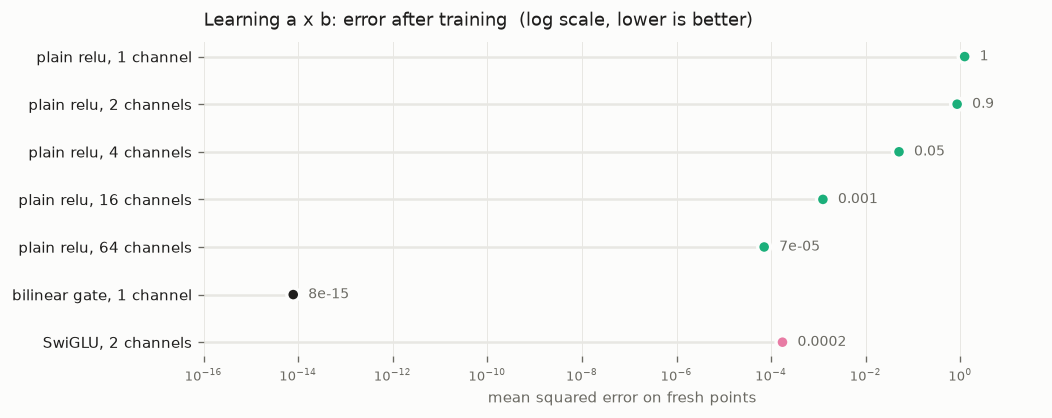

In [20]:
if HAVE_MPL:
    fig, ax = plt.subplots(figsize=(9, 3.4), dpi=120)
    fig.patch.set_facecolor(SURFACE); style(ax); ax.grid(axis="y", visible=False)
    names = [n for n, _ in results][::-1]
    errs = [e for _, e in results][::-1]
    colors = [COLOR["relu"] if n.startswith("plain") else COLOR["silu"] if n.startswith("SwiGLU") else INK for n in names]
    ax.hlines(range(len(names)), 1e-16, errs, color=GRID, lw=1.5)
    ax.scatter(errs, range(len(names)), color=colors, s=60, zorder=3, edgecolors=SURFACE, linewidths=2)
    for i, e in enumerate(errs):
        ax.annotate(f"{e:.1g}", (e, i), xytext=(9, 0), textcoords="offset points", color=INK2, fontsize=8.5, va="center")
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names, color=INK, fontsize=9)
    ax.set_xscale("log"); ax.set_xlim(1e-16, 50)
    ax.set_title("Learning a x b: error after training  (log scale, lower is better)", color=INK, fontsize=11, loc="left", pad=10)
    ax.set_xlabel("mean squared error on fresh points", color=INK2, fontsize=9)
    plt.show()
else:
    print("(plot skipped)")

The plain MLP needs sixteen channels to get its error down to about a thousandth, and it
never reaches zero — it's building a curved surface out of flat pieces. **One gated channel with
no bend at all is exact** to floating-point precision, with 8 weights against 65.

SwiGLU with two channels gets close but not exact by training alone, because its SiLU bends
the gate. (Two channels *can* do it exactly — exercise 2 finds the weights.)

That's the leading explanation for why gated MLPs train better: **a gated layer can let one
feature scale another, which a plain layer can only approximate.** Language is full of
that — *not* flipping *good*, a subject deciding which verb form applies. The strongest
evidence is from Shazeer's 2020 paper, which introduced SwiGLU: the *bilinear* variant, with
no activation anywhere, beat every plain MLP he tried. So the gain comes from the
multiplication, not from a cleverer curve. He offered no deeper theory, and nobody has a
complete one since. His paper attributes the success "as all else, to divine benevolence".

### Break it on purpose: the unfair comparison

A gated layer has three matrices where a plain one has two. Give both the same hidden width
and the gated layer simply has 50% more weights — any comparison between them is then
measuring size, not structure. It's an easy mistake, and it makes the gate look better than
it is.

The fix, used by Shazeer and by this repo, is to shrink the gated layer's hidden width to
2/3, so `3 × (2/3) = 2` matrices' worth of weights. With this repo's TinyStories width:

In [21]:
d_model, mult = 256, 4
plain_hidden = mult * d_model
naive_hidden = mult * d_model                                  # same width: the unfair version
fair_hidden = 64 * math.ceil(int(2 * mult * d_model / 3) / 64)  # 2/3 of it, rounded up to a multiple of 64

print(f"plain MLP        hidden {plain_hidden:>5}   2 matrices   {2 * d_model * plain_hidden:>8,} weights")
print(f"gated, same width hidden {naive_hidden:>5}   3 matrices   {3 * d_model * naive_hidden:>8,} weights   <- 50% bigger")
print(f"gated, 2/3 width  hidden {fair_hidden:>5}   3 matrices   {3 * d_model * fair_hidden:>8,} weights   <- within 3%")

plain MLP        hidden  1024   2 matrices    524,288 weights
gated, same width hidden  1024   3 matrices    786,432 weights   <- 50% bigger
gated, 2/3 width  hidden   704   3 matrices    540,672 weights   <- within 3%


682 would be exactly 2/3; rounding up to 704 keeps the matrices a shape GPU kernels like,
at the cost of 3% more weights. That's why a config saying `hidden_mult: 4` produces a
704-wide SwiGLU and a 1,024-wide plain MLP: the number means "the budget of a 4× plain
MLP", not a width.

---
## 8. Where the bends are in a transformer

Every block has two halves:

```
x ──→ norm ──→ attention ──→ + ──→ norm ──→ MLP ──→ + ──→ next block
│                           ↑    │                  ↑
└───────────────────────────┘    └──────────────────┘
```

Only one of them has an activation. Attention's four matrices — queries, keys, values,
output — are plain weighted sums with nothing after them. Its only bend is the softmax that
turns scores into weights, which is a different kind of function: it works across a whole
row of positions, not one number at a time. The norms, the embedding table and the output
layer have none either.

So the MLP is where the bend lives, and in a Llama-style model it is gated in **every**
block. The MLP type is a model-wide choice; nobody mixes gated and plain MLPs between
layers. And the MLP is also where most of the weights are. For the TinyStories config
(width 256, 8 query heads and 2 key/value heads of width 32, a 704-wide SwiGLU):

In [22]:
d, heads, kv_heads, hd, hidden = 256, 8, 2, 32, 704
attn = {"q": d * heads * hd, "k": d * kv_heads * hd, "v": d * kv_heads * hd, "o": heads * hd * d}
mlp = {"gate": d * hidden, "up": d * hidden, "down": hidden * d}
a, m = sum(attn.values()), sum(mlp.values())
print(f"attention  {a:>8,} weights   no activation")
print(f"MLP        {m:>8,} weights   gated, SiLU on the gate")
print(f"\nthe MLP is {m / (a + m):.0%} of each block")

attention   163,840 weights   no activation
MLP         540,672 weights   gated, SiLU on the gate

the MLP is 77% of each block


### The packaged version

`litterbox.model.mlp` holds both kinds, and a config picks between them with one line:
`mlp: {type: swiglu}` or `mlp: {type: gelu}`. Load section 6's weights into the repo's
`SwiGLU` and it must produce section 6's numbers:

In [23]:
from litterbox.model import GeluMLP, SwiGLU

packaged = SwiGLU(2, hidden_dim=2)
with torch.no_grad():
    packaged.gate_proj.weight.copy_(W_gate)
    packaged.up_proj.weight.copy_(W_up)
    packaged.down_proj.weight.copy_(W_down)
print("SwiGLU on section 6's weights:", [round(v, 3) for v in packaged(x).tolist()], "  hand trace:", [round(v, 3) for v in out.tolist()])

plain = GeluMLP(256, hidden_mult=4)
swiglu = SwiGLU(256, hidden_mult=4)
for layer in (plain, swiglu):
    print(f"{type(layer).__name__:8} hidden {layer.hidden_dim:>5}   {sum(p.numel() for p in layer.parameters()):>8,} weights")

SwiGLU on section 6's weights: [4.209, 6.361]   hand trace: [4.209, 6.361]
GeluMLP  hidden  1024    524,288 weights
SwiGLU   hidden   704    540,672 weights


Same numbers, and the same 524,288 against 540,672 as the budget cell. The swap between the
two is a config edit — `tests/test_config.py` builds a model with every MLP and norm pairing
and checks that each one generates through the same code.

### Gates beyond the MLP

The gate is older than SwiGLU and is spreading again. It first appeared in the **LSTM**
(1997) as a *forget gate*: a number between 0 and 1, computed from each token, that decides
how much of a running memory to keep. Two items on this repo's roadmap bring it back:

- **Gated DeltaNet**, in the linear-attention family, keeps a fixed-size memory instead of a
  KV cache, and scales that memory by a per-token gate before each write — the LSTM's forget
  gate, reinvented.
- **Gated attention** puts a sigmoid gate on each attention head's output, and is reported
  to stabilise training and stop heads from piling their weight onto the first token.

Same mechanism every time: a second weighted sum, squashed, multiplying the first.

---
## What to remember

| what | why |
|---|---|
| matrices without a bend collapse into one | depth is worthless until something non-straight sits between layers |
| the slope matters more than the curve | gradients are multiplied by it at every layer on the way back |
| sigmoid's slope is at most 0.25 | twenty of them shrink a gradient five trillion times |
| ReLU's slope is exactly 0 for negatives | a dead unit gets no gradient, and no optimiser can amplify zero |
| GELU and SiLU are ReLU with a rounded corner | nearly the same curve; the choice is mostly lineage |
| a gate is a number you multiply by | computed from the input, it decides how much of the content passes |
| gated = two sums side by side, then multiply | one feature can scale another, which a plain layer can only approximate |
| SwiGLU = the gated MLP with SiLU on the gate | the MLP in Llama-style models, in every block |
| compare at equal weights: 2/3 hidden width | otherwise the gated layer is just 50% bigger |

Two traps here produce no error at all. The sigmoid stack trains, reports a loss, and has
first layers that never learn. The dead ReLU layer has a loss that simply stops improving.
The checks that catch them measure what training sees — the gradient at every layer, the
units that never switch on — not the output.

---

## Exercises

1. **Kinks for a curve.** Build `sin(x)` on `-π..π` by hand from ReLU channels, placing the
   kinks yourself. How many channels do you need for a largest error below 0.05? Below 0.01?
2. **SwiGLU does `a × b` exactly.** Two channels are enough. Find the weights. *(Hint: what is
   `silu(z) - silu(-z)`?)* Check your answer against section 7's target.
3. **Rescue the sigmoid stack.** Find the starting weight scale that keeps the 20-layer sigmoid
   stack's gradients as level as possible. Does it get close to tanh? What's still wrong?
   *(Hint: what is the average output of a sigmoid?)*
4. **Leaky ReLU.** `max(0.01·x, x)` gives negatives a slope of 0.01 instead of 0. Add it to the
   dead-unit experiment. Does it revive the units, and how fast compared with GELU?
5. **Does the gate's curve matter?** Rerun section 7 with GLU, ReGLU, GEGLU, SwiGLU and bilinear
   gates at 2 channels each, over three seeds. Is the ordering stable?
6. **Make it real.** Add `GeGLU` to `src/litterbox/model/mlp.py` — SwiGLU with GELU on the gate,
   sharing `swiglu_hidden_dim` — register it as `geglu` in `model/build.py` and in the config
   schema, and give it an oracle test like SwiGLU's in `tests/test_norm_mlp.py`. It's also the
   third MLP, which is the trigger `DEFERRED.md` names for unifying the registries: decide
   whether it fires.